# 05-repertoire-similarity

In [1]:
import scanpy as sc
import scirpy as ir
import numpy as np
import json
from pathlib import Path
import pandas as pd
import muon as mu
import anndata as ad
import gzip
import shutil
from concurrent.futures import ThreadPoolExecutor
import warnings
warnings.filterwarnings('ignore')

DATA = Path("data")

N_SAMPLES = [
  "LN1",
  "LN2",
  "LN3",
  "LN4",
  "LN5",
  "LN6",
  "EN1",
  "EN2",
  "EN3",
  "CN1",
  "CN2",
  "RN1",
  "RN2",
  "RN3",
]

T_SAMPLES = [
  "LT1",
  "LT2",
  "LT3",
  "LT4",
  "LT5",
  "LT6",
  "ET1",
  "ET2",
  "ET3",
  "CT1",
  "CT2",
  "RT1",
  "RT2",
  "RT3",
]

B_SAMPLES = [
  "LB6",
  "RB1",
  "RB2",
  "RB3",
]

SAMPLES = N_SAMPLES + T_SAMPLES + B_SAMPLES

def sample_tissue(sample: str) -> str:
  if sample in B_SAMPLES:
    return "Blood"
  if sample in N_SAMPLES:
    return "Normal"
  if sample in T_SAMPLES:
    return "Tumor"
  raise ValueError(f"Unknown sample: {sample}")

Matplotlib is building the font cache; this may take a moment.
/Users/alegator1209/micromamba/envs/pytcr/lib/python3.10/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
def extract_file(path: Path) -> Path:
  extracted = Path(str(path).partition(".gz")[0])

  with gzip.open(path, 'rb') as f_in:
    with open(extracted, 'wb') as f_out:
      shutil.copyfileobj(f_in, f_out)

  return extracted

def extract_mtx_data(dir: Path, prefix: str):
  extract_file(dir / f"{prefix}barcodes.tsv.gz")
  extract_file(dir / f"{prefix}genes.tsv.gz")
  extract_file(dir / f"{prefix}matrix.mtx.gz")

In [3]:
def find_prefix(dir: Path) -> str:
  matches = list(dir.glob("*barcodes.tsv.gz"))
  if len(matches) != 1:
    raise ValueError(f"Expected exactly one barcodes.tsv.gz file in {dir}, found {len(matches)}")
  return matches[0].name.removesuffix("barcodes.tsv.gz")

def read_sample(dir: Path) -> mu.MuData:
  print(f"Reading sample {dir.name}")
  prefix = find_prefix(dir)
  extract_mtx_data(dir, prefix)

  adata = sc.read_10x_mtx(dir, prefix=prefix)
  adata.var_names_make_unique()
  adata_tcr = ir.io.read_10x_vdj(dir / f"{prefix}filtered_contig_annotations.csv.gz")

  mdata = mu.MuData({'gex': adata, 'airr': adata_tcr})
  mdata['gex'].obs['sample'] = dir.name
  mdata['gex'].obs['source'] = sample_tissue(dir.name)
  mdata.update()

  return mdata

In [4]:
with ThreadPoolExecutor(max_workers=8) as executor:
  samples = list(executor.map(lambda s: read_sample(DATA / s), SAMPLES))

Reading sample LN1
Reading sample LN2
Reading sample LN3
Reading sample LN4
Reading sample LN5
Reading sample LN6
Reading sample EN1
Reading sample EN2
Reading sample EN3
Reading sample CN1
Reading sample CN2
Reading sample RN1
Reading sample RN2
Reading sample RN3
Reading sample LT1
Reading sample LT2
Reading sample LT3
Reading sample LT4
Reading sample LT5
Reading sample LT6
Reading sample ET1
Reading sample ET2
Reading sample ET3
Reading sample CT1
Reading sample CT2
Reading sample RT1
Reading sample RT2
Reading sample RT3
Reading sample LB6
Reading sample RB1
Reading sample RB2
Reading sample RB3


In [5]:
def preprocess(sample: mu.MuData) -> mu.MuData:
  sc.pp.filter_genes(sample["gex"], min_cells=10)
  sc.pp.filter_cells(sample["gex"], min_genes=100)
  return sample

def integrate(samples: list[mu.MuData]) -> mu.MuData:
  gex = ad.concat(
    {s.obs["gex:sample"].iloc[0]: s["gex"] for s in samples},
    index_unique='-',
    join='outer',
  )

  airr = ad.concat(
    {s.obs["gex:sample"].iloc[0]: s["airr"] for s in samples},
    index_unique='-',
    join='outer',
  )

  mdata = mu.MuData({'gex': gex, 'airr': airr})
  mu.pp.intersect_obs(mdata)
  mdata.update()
  return mdata

In [6]:
samples = [preprocess(s) for s in samples]
mdata = integrate(samples)
mdata

MuData object with n_obs × n_vars = 110365 × 17474
  2 modalities
    gex:	110365 × 17474
      obs:	'sample', 'source', 'n_genes'
    airr:	110365 × 0
      obsm:	'airr'

In [7]:
sc.pp.normalize_per_cell(mdata["gex"])
sc.pp.log1p(mdata["gex"])
sc.pp.highly_variable_genes(mdata["gex"], flavor="cell_ranger", n_top_genes=5000)
sc.tl.pca(mdata["gex"])
sc.pp.neighbors(mdata["gex"])
sc.tl.umap(mdata["gex"])
mdata.update()
mdata

MuData object with n_obs × n_vars = 110365 × 17474
  2 modalities
    gex:	110365 × 17474
      obs:	'sample', 'source', 'n_genes', 'n_counts'
      var:	'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg', 'pca', 'neighbors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'
    airr:	110365 × 0
      obsm:	'airr'

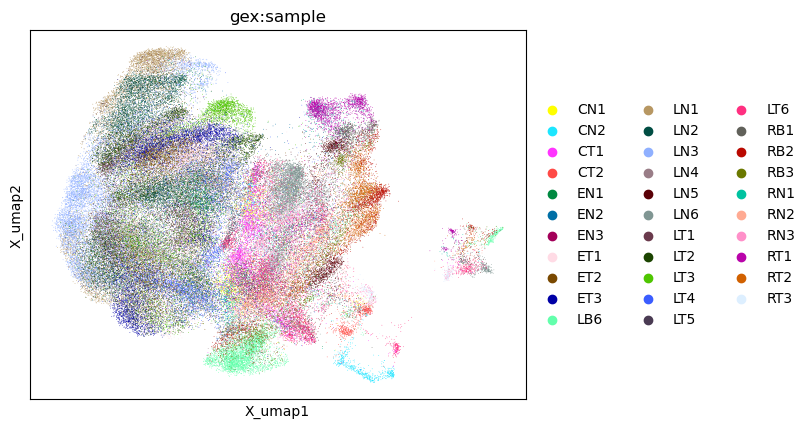

In [8]:
mu.pl.embedding(
  mdata,
  basis="gex:umap",
  color=["gex:sample"],
  ncols=3,
  wspace=0.7,
)

In [9]:
ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)

In [10]:
mdata['airr'].obs.groupby('receptor_subtype').count()

,receptor_type,chain_pairing
receptor_subtype,,
IGH,110,110
IGH+IGK,10,10
TRA+TRB,99268,99268
TRG+TRD,1,1
ambiguous,2,2
multichain,499,499
no IR,10475,10475


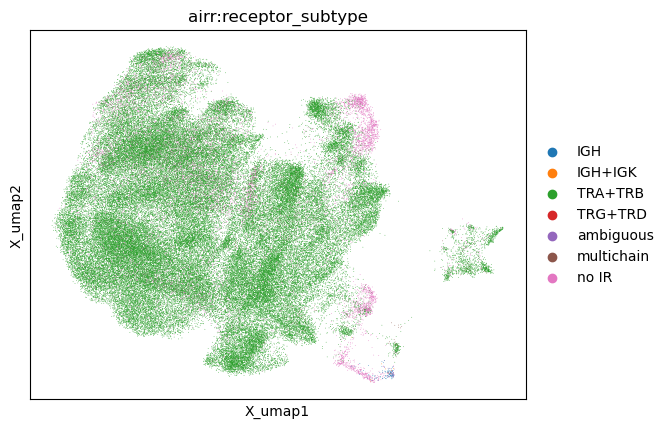

In [11]:
mu.pl.embedding(
  mdata,
  basis="gex:umap",
  color=["airr:receptor_subtype"],
  ncols=3,
  wspace=0.7,
)

In [12]:
mu.pp.filter_obs(mdata, "airr:receptor_subtype", lambda x: x == "TRA+TRB")

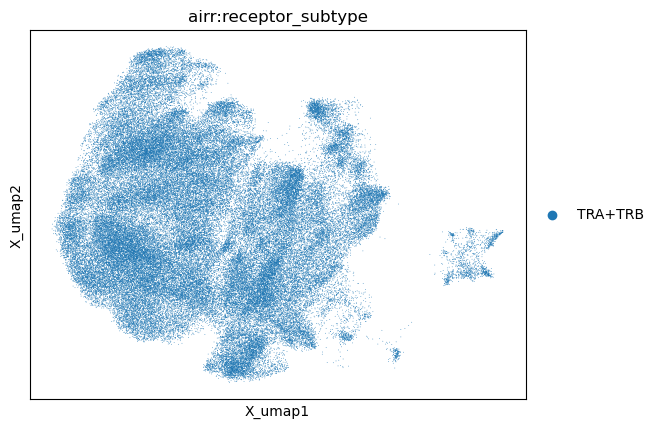

In [13]:
mu.pl.embedding(
  mdata,
  basis="gex:umap",
  color=["airr:receptor_subtype"],
  ncols=3,
  wspace=0.7,
)

In [14]:
mu.pp.filter_obs(mdata, "airr:chain_pairing", lambda x: ~np.isin(x, ["no IR", "orphan VDJ", "orphan VJ", "multichain"]))

In [15]:
mdata.obs.groupby("airr:chain_pairing").count()

,gex:sample,gex:source,gex:n_genes,gex:n_counts,airr:receptor_type,airr:receptor_subtype
airr:chain_pairing,,,,,,
extra VDJ,2499,2499,2499,2499,2499,2499
extra VJ,3402,3402,3402,3402,3402,3402
single pair,55319,55319,55319,55319,55319,55319
two full chains,750,750,750,750,750,750


In [16]:
ir.pp.ir_dist(mdata)
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only")
ir.tl.clonotype_network(mdata, min_cells=2)

In [17]:
mdata.obs.groupby("gex:source", dropna=False).size()

gex:source
Blood      4146
Normal    24933
Tumor     32891
dtype: int64

In [18]:
df, dst, lk = ir.tl.repertoire_overlap(mdata, "gex:sample", inplace=False)
df.head()

clone_id,0,1,10,100,1000,10000,10001,10002,10003,10004,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
gex:sample,,,,,,,,,,,,,,,,,,,,,
CN1,0.0,0.0,0.0,0.0,0.0,5.0,1.0,1.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
CN2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CT1,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CT2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
EN1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


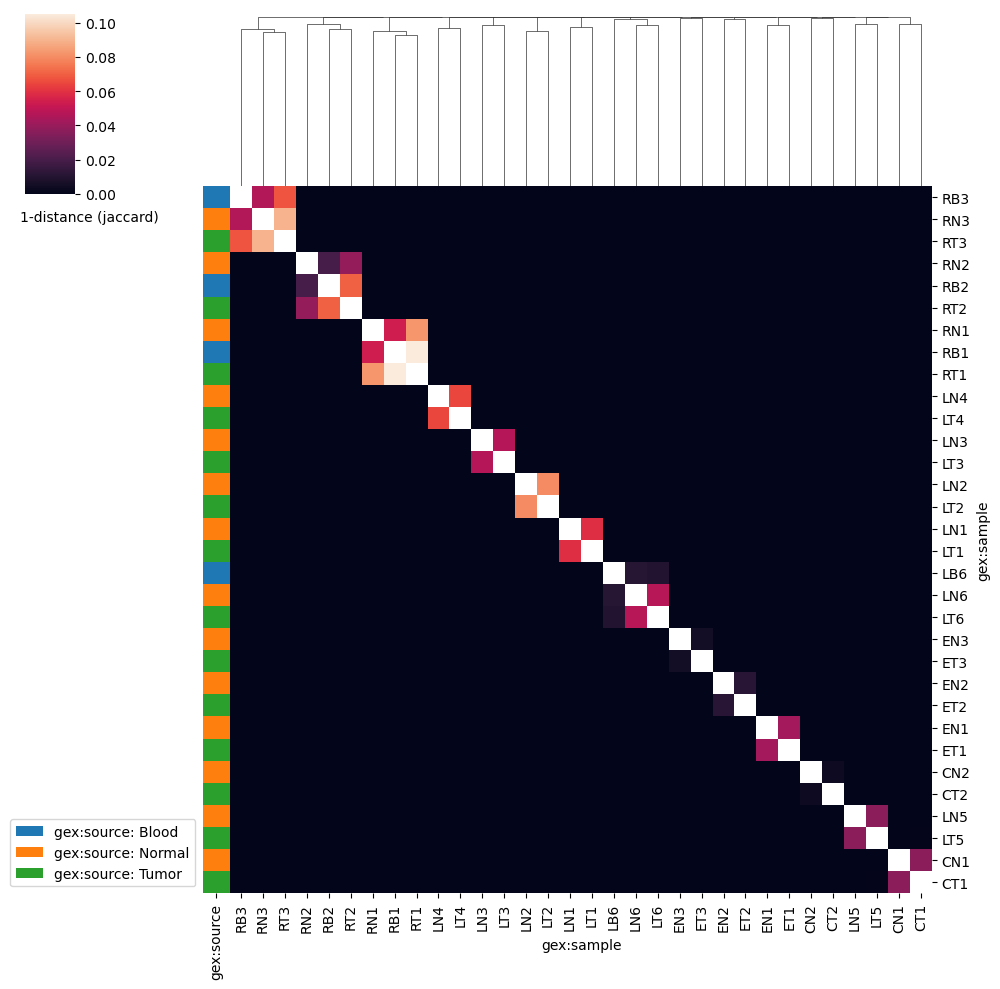

In [19]:
_ = ir.pl.repertoire_overlap(
    mdata,
    "gex:sample",
    heatmap_cats=["gex:source"],
    yticklabels=True,
    xticklabels=True,
)

In [20]:
ir.tl.repertoire_overlap(mdata, "gex:sample")

In [21]:
mdata['airr'].uns['repertoire_overlap']

{'weighted': clone_id       0     1      2    3    4    5     6     7    8     9  ...  \
 gex:sample                                                           ...   
 CN1          0.0   0.0    0.0  0.0  0.0  0.0   0.0   0.0  0.0   0.0  ...   
 CN2          0.0   0.0    0.0  0.0  0.0  0.0   0.0   0.0  0.0   0.0  ...   
 CT1          0.0   0.0    0.0  0.0  0.0  0.0   0.0   0.0  0.0   0.0  ...   
 CT2          0.0   0.0    0.0  0.0  0.0  0.0   0.0   0.0  0.0   0.0  ...   
 EN1          0.0   0.0    0.0  0.0  0.0  0.0   0.0   0.0  0.0   0.0  ...   
 EN2          0.0   0.0    0.0  0.0  0.0  0.0   0.0   0.0  0.0   0.0  ...   
 EN3          0.0   0.0    0.0  0.0  0.0  0.0   0.0   0.0  0.0   0.0  ...   
 ET1          0.0   0.0    0.0  0.0  0.0  0.0   0.0   0.0  0.0   0.0  ...   
 ET2          0.0   0.0    0.0  0.0  0.0  0.0   0.0   0.0  0.0   0.0  ...   
 ET3          0.0   0.0    0.0  0.0  0.0  0.0   0.0   0.0  0.0   0.0  ...   
 LB6          0.0   0.0    0.0  0.0  0.0  0.0   0.0   0.0  0.0  

In [22]:
lt5_clonotypes = df.loc["LT5"] > 0
ln5_clonotypes = df.loc["LN5"] > 0

shared_lt5_ln5 = ln5_clonotypes & lt5_clonotypes
shared_lt5_ln5 = int(shared_lt5_ln5.sum())

print(f"Number of clonotypes shared between LN5 and LT5: {shared_lt5_ln5}")

Number of clonotypes shared between LN5 and LT5: 85


<Axes: title={'center': 'Repertoire overlap between Normal and Blood'}, xlabel='Clonotype size in Normal', ylabel='Clonotype size in Blood'>

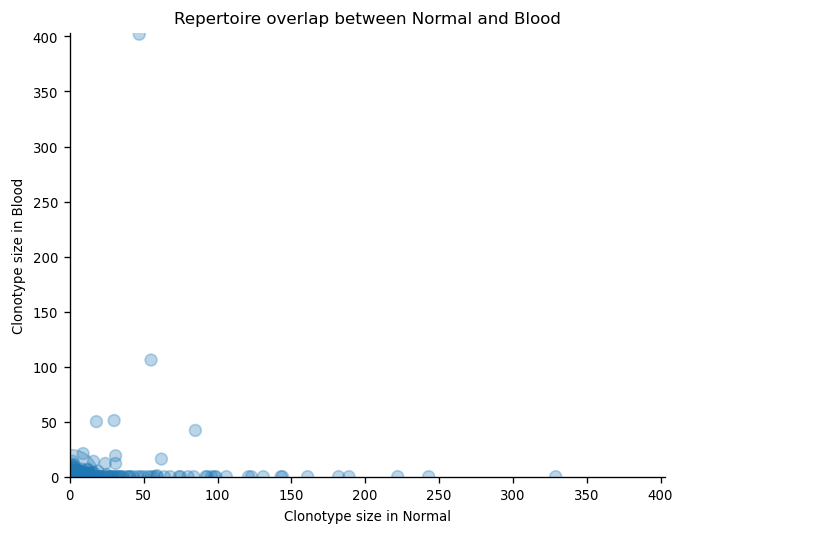

In [23]:
ir.pl.repertoire_overlap(mdata, "gex:source", pair_to_plot=["Normal", "Blood"], fig_kws={"dpi": 120})

In [24]:
tissue_sizes, _, _ = ir.tl.repertoire_overlap(mdata, "gex:source", inplace=False)

tissue_size_corr = tissue_sizes.T.corr(method="pearson")
tissue_size_corr

gex:source,Blood,Normal,Tumor
gex:source,,,
Blood,1.000000,0.091700,0.503929
Normal,0.091700,1.000000,0.230036
Tumor,0.503929,0.230036,1.000000


In [25]:
multi_sample_clonotypes = (df > 0).sum(axis=0) >= 2
multi_sample_clonotypes = int(multi_sample_clonotypes.sum())

print(f"Number of multisample clonotypes: {multi_sample_clonotypes}")

Number of multisample clonotypes: 1666


In [26]:
output = {
  "shared_lt5_ln5": shared_lt5_ln5,
  "multi_sample_clonotypes": multi_sample_clonotypes,
  "correlation_tissues": "blood x tumor",
  "correlation_value": 0.504,
  "cluster_by": "patient"
}

print(json.dumps(output, indent=2))

# with open('output.json', 'w') as f:
#     json.dump(output, f, indent=2)
# print('Results saved to output.json:')

{
  "shared_lt5_ln5": 85,
  "multi_sample_clonotypes": 1666,
  "correlation_tissues": "blood x tumor",
  "correlation_value": 0.504,
  "cluster_by": "patient"
}
